Lessons learned:
- initial_t_inner as given by the blackbody temperature using the parameters L, t_exp, and v_start, shows no correlation with pass/fail status.

# Read Data

In [ ]:
import emulator.interpolator.util as util
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import corner
import os

folder_path = os.path.dirname('C:/Users/mikel/Desktop/new_atomic_runs/')
param_names = ['id', 'log_lsun', 't_exp', 'v_start', 'X', 'Z', 'n']
limits = [(7.32, 9.12), (13, 17.5), (5600, 7000), (0.55, 0.85), (5e-4, 5e-2), (9, 11)]
file_name = 'new_atomic_runs_indexed'

# Saved indexed copy
if False:
    import emulator.interpolator.util as util
    import os
    util.save_runs(folder_path, param_names, file_name)

# Read the data
param_names, X_indexed, y, wav_mod = util.read_runs(file_name)
grid = pd.read_csv(os.path.join(folder_path, 'grid.csv'))

X_indexed = pd.DataFrame(X_indexed, columns=param_names)
X = X_indexed.drop('id', axis=1)
ran_i = X_indexed['id'].to_numpy(int)
all_i = grid['id'].to_numpy(int)
passed_i = np.array([x for x in all_i if x in ran_i])
failed_i = np.array([x for x in all_i if x not in ran_i])

passed_mask = np.array([x in passed_i for x in grid['id']])
failed_mask = np.array([x in failed_i for x in grid['id']])
X_passed = grid[passed_mask][param_names].drop('id', axis=1)
X_failed = grid[failed_mask][param_names].drop('id', axis=1)

In [ ]:
# Create new grid with all the failed runs
if False:
    fail_grid = grid.copy().set_index('id')
    mask = np.isin(fail_grid.index, failed_i)
    fail_grid = fail_grid[mask]
    fail_grid.to_csv('grid.csv')

In [5]:
print('Passed:', len(X_passed))
print('Failed:', len(X_failed))

Passed: 8556
Failed: 1444


In [7]:
print(failed_i[:10])

[ 0  2  5  7 13 22 29 33 35 46]


# Failure Classification

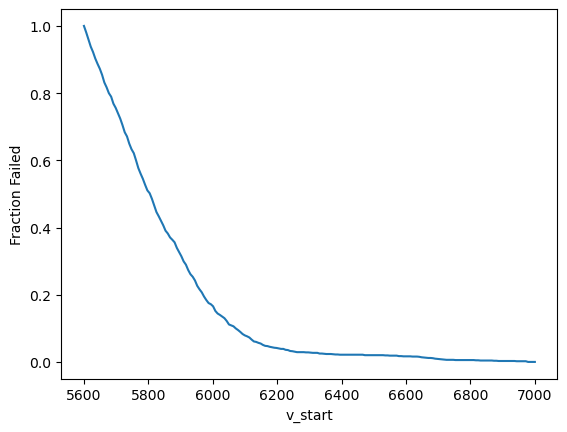

In [11]:
# Strong and simple correlation between v_start and failure status
v_start = np.linspace(limits[2][0], limits[2][1], 200)
frac_failed = [1 - np.sum(X_failed['v_start'] < x) / len(X_failed) for x in v_start]
plt.plot(v_start, frac_failed)
plt.xlabel('v_start')
plt.ylabel('Fraction Failed')
plt.show()

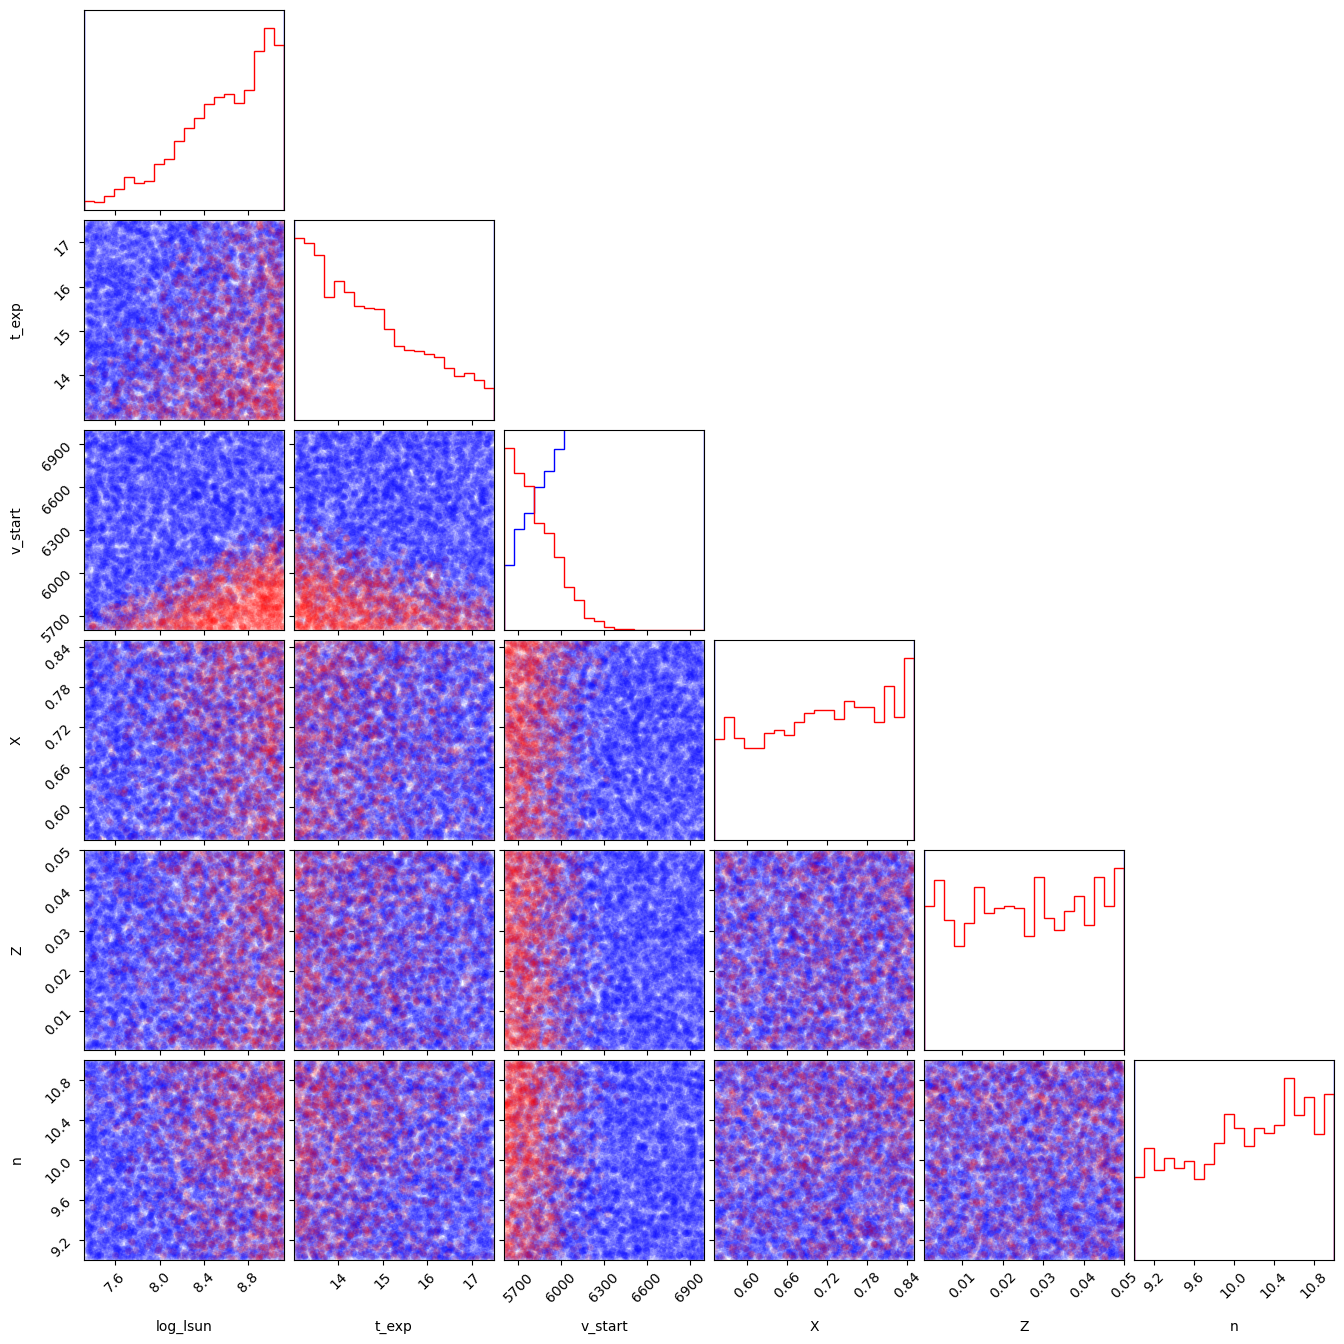

In [9]:
from sklearn.linear_model import LogisticRegression
import numpy as np

u = np.vstack([X_passed.values, X_failed.values])
v = np.hstack([
    np.zeros(len(X_passed)), # Passed = 0
    np.ones(len(X_failed))   # Failed = 1
])

clf = LogisticRegression(max_iter=1000000, class_weight={0: 1, 1: 2})
clf.fit(u, v)

v_pred = clf.predict(u)
pass_pred = u[v_pred == 0]
fail_pred = u[v_pred == 1]

# Plot successful
fig = corner.corner(
    pass_pred,
    labels=X.columns,
    range=limits,
    bins = 20,
    color='blue',
    plot_contours=False,
    plot_datapoints=True,
    plot_density=False,
    data_kwargs={'ms': 5}
)

# Plot failed
corner.corner(
    fail_pred,
    fig=fig,
    labels=X.columns,
    range=limits,
    bins = 20,
    color='red',
    plot_contours=False,
    plot_datapoints=True,
    plot_density=False,
    data_kwargs={'ms': 5}
)

plt.show()

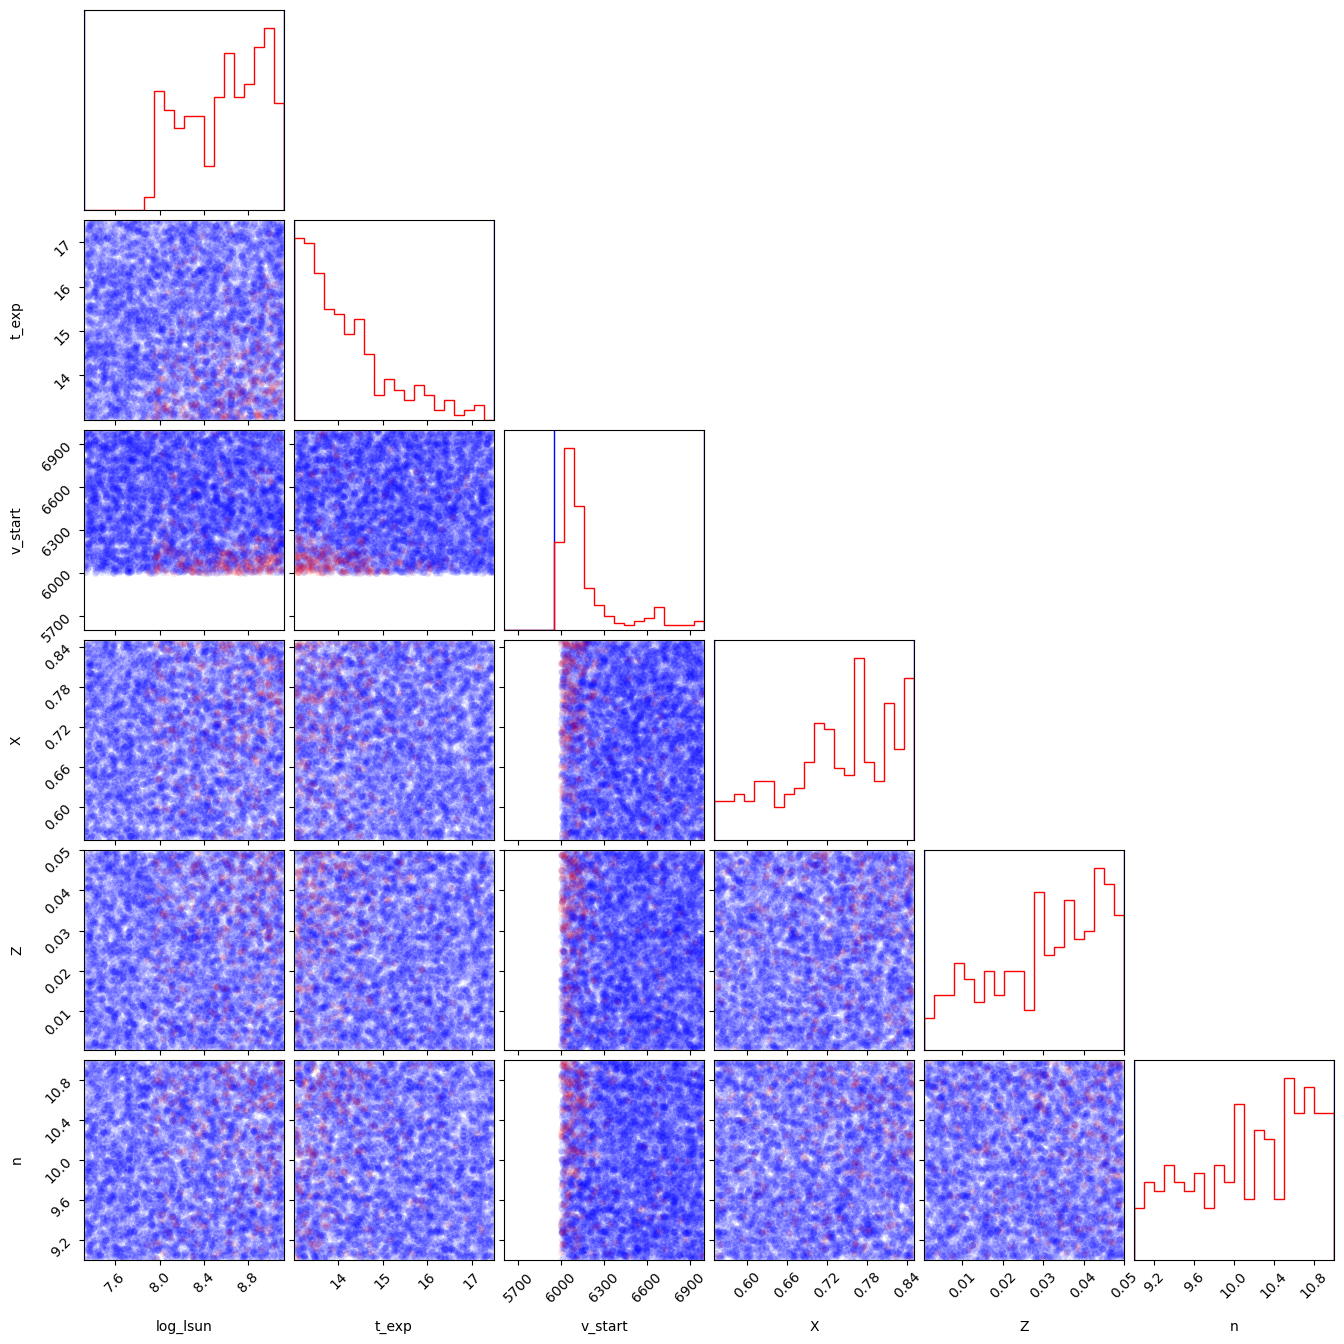

In [12]:
# Plot successful
mask = X_passed['v_start'] > 6000
fig = corner.corner(
    X_passed[mask].values,
    labels=X.columns,
    range=limits,
    bins = 20,
    color='blue',
    plot_contours=False,
    plot_datapoints=True,
    plot_density=False,
    data_kwargs={'ms': 5}
)

# Plot failed
mask = X_failed['v_start'] > 6000
corner.corner(
    X_failed[mask].values,
    fig=fig,
    labels=X.columns,
    range=limits,
    bins = 20,
    color='red',
    plot_contours=False,
    plot_datapoints=True,
    plot_density=False,
    data_kwargs={'ms': 5}
)

plt.show()

In [ ]:
# Rename spectra using proper indices
import json

folder = os.path.dirname('C:/Users/mikel/Desktop/5000_runs_2/')
params = pd.read_json(os.path.join(folder, 'parameters.log'), lines=True)
grid = pd.read_csv(os.path.join(folder, 'grid.csv'))

for index in range(len(params)):
    row = params.iloc[index]
    id = grid.iloc[index]['id'] # This is the true ID

    # First rename to temp so there's no overrides
    old_path = os.path.join(folder, str(index) + '_sed.csv')
    new_path = os.path.join(folder, str(index) + '_temp_sed.csv')
    os.rename(old_path, new_path)

    # Final rename
    # old_path = os.path.join(folder, str(index) + '_temp_sed.csv')
    # new_path = os.path.join(folder, str(id) + '__sed.csv')
    # os.rename(old_path, new_path)

# params_path = os.path.join(folder, 'parameters_new.log')
# with open(params_path, 'a') as file:
#     json.dump(params, file)

# for i, row in enumerate(params.rows):
#     print(row)
#     break

# SED names are the indices of each grid.csv line, so change the ID in the parameters.log entry and the SED name to the ID in grid.csv

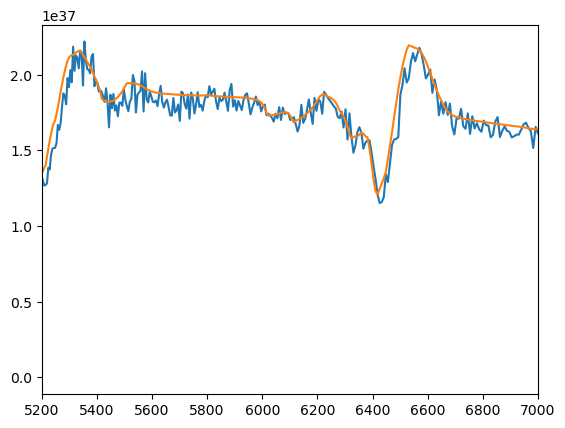

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

folder = os.path.dirname('C:/Users/mikel/Desktop/10000_runs/')
params = pd.read_json(os.path.join(folder, 'parameters.log'), lines=True)
index = np.random.randint(0, len(params))
id = params.iloc[index]['id']

df = pd.read_csv(os.path.join(folder, str(id) + '_virtual_sed.csv'))
plt.plot(df['wavelength'], df['L_density'])
df = pd.read_csv(os.path.join(folder, str(id) + '_integrated_sed.csv'))
plt.plot(df['wavelength'], df['L_density'])
plt.xlim(5200, 7000)
plt.show()